# Transit Route Generation Evaluation

This notebook evaluates two approaches for transit network design:
- **LC (Learning-based Construction)** – pure neural route generator
- **Neural BCO (Bee Colony Optimization with neural initialization)**

Tested on **Mandl's benchmark** and **Tartu real-world network**.

---

## 1. Setup & Configuration

In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import pickle
from pathlib import Path
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader
from tqdm import tqdm

# Project-specific imports
from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.torch_utils import dump_routes
from connectpt.routes_generator import bee_colony
import connectpt.routes_generator.utils as lrnu

In [2]:
# Root paths (adjust only here if needed)
ROOT_DIR = Path.cwd().parent.parent
DATA_DIR = ROOT_DIR / "examples/data"
CFG_DIR = ROOT_DIR / "connectpt/routes_generator/cfg"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples/data/model_weights/inductive_random_graphs_weighted_connectivity.pt"

# Verify paths
print("Root directory:", ROOT_DIR)
print("Config directory:", CFG_DIR)
print("Model weights exist:", MODEL_WEIGHTS_PATH.exists())

Root directory: d:\PythonProjects\connectpt
Config directory: d:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Model weights exist: True


## 2. Load Benchmark Instances

### 2.1 Mandl's Benchmark (Classic 15-node instance)

In [3]:
def load_mandl_instance():
    data_dir = DATA_DIR / "benchmark"
    instance_name = "Mumford0"

    # Coordinates
    coords_path = data_dir / f"{instance_name}Coords.txt"
    node_locs = torch.tensor(np.genfromtxt(coords_path, skip_header=1), dtype=torch.float32)

    # Travel times (in seconds)
    tt_path = data_dir / f"{instance_name}TravelTimes.txt"
    street_adj = torch.tensor(np.genfromtxt(tt_path), dtype=torch.float32) * 60

    # Demand matrix
    dmd_path = data_dir / f"{instance_name}Demand.txt"
    demand = torch.tensor(np.genfromtxt(dmd_path), dtype=torch.float32)

    print(f"Mandl instance loaded:")
    print(f"  Nodes: {node_locs.shape[0]}, Demand shape: {demand.shape}")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

# Load Mandl
input_tensors_mandl = load_mandl_instance()

Mandl instance loaded:
  Nodes: 30, Demand shape: torch.Size([30, 30])


### 2.2 Tartu Real-World Network (199 nodes)

In [4]:
def load_tartu_instance():
    data_dir = DATA_DIR / "tartu"

    # Load graph
    with open(data_dir / "bus_graph_Tartu.pkl", "rb") as f:
        G = pickle.load(f)

    # Load demand (OD matrix)
    OD = pd.read_csv(data_dir / "OD_matrix_Tartu.csv", index_col=0)
    demand = torch.tensor(OD.values, dtype=torch.float32)

    # Sort nodes to match OD matrix order
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Node coordinates
    node_locs = torch.tensor([[G.nodes[n]['x'], G.nodes[n]['y']] for n in nodes], dtype=torch.float32)

    # Build symmetric travel time matrix
    n = len(nodes)
    inf = float('inf')
    adj_matrix = np.full((n, n), inf, dtype=np.float32)
    np.fill_diagonal(adj_matrix, 0.0)

    for u, v, data in G.edges(data=True):
        if 'time_min' in data:
            t = data['time_min']
            i, j = node_to_idx[u], node_to_idx[v]
            adj_matrix[i, j] = t
            adj_matrix[j, i] = t

    street_adj = torch.tensor(adj_matrix)
    street_adj[street_adj == inf] = torch.inf

    print(f"Tartu instance loaded: {n} nodes")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

# Uncomment to use Tartu instead
# input_tensors = load_tartu_instance()
input_tensors = input_tensors_mandl  # Default: Mandl

## 3. Evaluation Parameters

In [5]:
eval_params = {
    "dataset_name": "tensor",
    "n_routes": 6,
    "min_route_len": 2,
    "max_route_len": 8,
    "demand_time_weight": 0.33,
    "route_time_weight": 0.33,
    "median_connectivity_weight": 0.33,
    "run_name": "mandl_eval",
    "model_weights": str(MODEL_WEIGHTS_PATH)
}

# Toggle between classic BCO and Neural BCO.
USE_NEURAL_BCO = True
BCO_BASE_CFG_NAME = "neural_bco_mumford" if USE_NEURAL_BCO else "bco_mumford"
BCO_METHOD_LABEL = "Neural BCO" if USE_NEURAL_BCO else "Classic BCO"
BCO_RUN_PREFIX = "neural_bco" if USE_NEURAL_BCO else "bco"

# Parameters for the adjustment-degree experiments.
# Set ADJUSTMENT_DEGREE_WEIGHT = 0.0 to disable all adjustment-based branches.
ADJUSTMENT_DEGREE_WEIGHT = 1.0
ADJUSTMENT_DEGREE_GAP = 0.1
ADJUSTMENT_DEGREE_TARGET = 0.5
CURRENT_ADJUSTMENT_MODE = "current"
PAPER_ADJUSTMENT_MODE = "paper"
RAW_ADJUSTMENT_OBJECTIVE = "raw"
TARGET_ADJUSTMENT_OBJECTIVE = "target"


## 4. Method 1: Learning-based Construction (LC)

In [6]:
# Load config
cfg_lc = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="eval_model_mumford",
    params=eval_params
)

# Build dataset and dataloader
test_ds = get_dataset_from_config(cfg_lc.eval.dataset, tensors=input_tensors)
test_dl = DataLoader(test_ds, batch_size=cfg_lc.batch_size)

# Initialize model
DEVICE, run_name_lc, _, cost_obj, model_lc = lrnu.process_standard_experiment_cfg(
    cfg_lc, run_name_prefix="lc_", weights_required=True
)

print(f"Running LC on {DEVICE}...")

_, unserved_lc, metrics_lc, routes_lc = eval_model(
    model_lc,
    test_dl,
    cfg_lc.eval,
    cost_obj,
    n_samples=cfg_lc.get("n_samples", 1),
    return_routes=True,
    silent=True,
    device=DEVICE
)

dump_routes(run_name_lc, routes_lc.cpu())

print("\nLC Results")
print("-" * 50)
print(f"Cost: {metrics_lc['cost'].item():.4f}")
print(f"Unserved demand (%): {metrics_lc['$d_{un}$'].item():.2f}")
print(f"Average Travel Time (ATT): {metrics_lc['ATT'].item():.4f}")
print(f"Routes:\n{routes_lc}")

Running LC on cpu...

LC Results
--------------------------------------------------
Cost: 2.7603
Unserved demand (%): 25.92
Average Travel Time (ATT): 21.8152
Routes:
tensor([[[29, 27, 16, 28,  0, 12,  8],
         [ 5,  6, 16,  7, 14, 23, -1],
         [ 9,  3, 11, 17,  0, 26, -1],
         [18,  0, 25,  7, 20, -1, -1],
         [21,  6, 13,  0, 22, -1, -1],
         [ 1, 14,  7, 10, 15, -1, -1]]])


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:302: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


## 5. Method 2: BCO Variants (Classic Or Neural)


In [ ]:
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.cpu()
    return get_batch_tensor_from_routes(routes).cpu()


def compute_adjustment_metrics(candidate_routes, reference_routes, symmetric_routes, gap):
    candidate_routes = as_route_tensor(candidate_routes)
    reference_routes = as_route_tensor(reference_routes)
    max_len = max(candidate_routes.shape[-1], reference_routes.shape[-1])
    if candidate_routes.shape[-1] < max_len:
        candidate_routes = torch.nn.functional.pad(
            candidate_routes, (0, max_len - candidate_routes.shape[-1]), value=-1
        )
    if reference_routes.shape[-1] < max_len:
        reference_routes = torch.nn.functional.pad(
            reference_routes, (0, max_len - reference_routes.shape[-1]), value=-1
        )
    return {
        "current": get_adjustment_degrees(
            candidate_routes,
            reference_routes,
            symmetric_routes=symmetric_routes,
            gap=gap,
            mode="current",
        ).mean().item(),
        "paper": get_adjustment_degrees(
            candidate_routes,
            reference_routes,
            symmetric_routes=symmetric_routes,
            gap=gap,
            mode="paper",
        ).mean().item(),
    }


def get_active_adjustment_penalty(adjustment_metrics, penalty_mode, penalty_objective, target):
    raw_value = adjustment_metrics[penalty_mode]
    if penalty_objective == RAW_ADJUSTMENT_OBJECTIVE:
        return raw_value
    if penalty_objective == TARGET_ADJUSTMENT_OBJECTIVE:
        return abs(raw_value - target)
    raise ValueError(f"Unsupported adjustment objective: {penalty_objective}")


def get_cost_settings(cost_obj_local):
    return {
        "demand_time_weight": float(getattr(cost_obj_local, "demand_time_weight", 0.0)),
        "route_time_weight": float(getattr(cost_obj_local, "route_time_weight", 0.0)),
        "median_connectivity_weight": float(getattr(cost_obj_local, "median_connectivity_weight", 0.0)),
        "constraint_violation_weight": float(getattr(cost_obj_local, "constraint_violation_weight", 0.0)),
    }


def run_bco_variant(cfg, label):
    test_dl_bco = DataLoader(test_ds, batch_size=cfg.batch_size)
    use_neural_bees = cfg.get("neural_bees", USE_NEURAL_BCO)
    prefix = "neural_bco_" if use_neural_bees else "bco_"

    device, run_name, sum_writer, cost_obj_local, bee_model_local = lrnu.process_standard_experiment_cfg(
        cfg,
        prefix,
        weights_required=use_neural_bees,
    )

    if bee_model_local is not None:
        bee_model_local.eval()

    penalty_mode = cfg.get("adjustment_degree_mode", CURRENT_ADJUSTMENT_MODE)
    penalty_objective = cfg.get("adjustment_degree_objective", RAW_ADJUSTMENT_OBJECTIVE)
    penalty_target = cfg.get("adjustment_degree_target", ADJUSTMENT_DEGREE_TARGET)
    cost_settings = get_cost_settings(cost_obj_local)

    print(f"Running {label} on {device}...")

    test_output = lrnu.test_method(
        bee_colony,
        test_dl_bco,
        cfg.eval,
        cfg.init,
        cost_obj_local,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        device=device,
        bee_model=bee_model_local,
        return_routes=True,
        routes_tensor=routes_lc,
        silent=True,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", ADJUSTMENT_DEGREE_GAP),
        adjustment_degree_mode=penalty_mode,
        adjustment_degree_objective=penalty_objective,
        adjustment_degree_target=penalty_target,
    )

    routes = test_output[-1]
    metrics = test_output[-2]
    unserved = test_output[-3]
    adjustment_metrics = compute_adjustment_metrics(
        routes,
        routes_lc,
        cost_obj_local.symmetric_routes,
        cfg.get("adjustment_degree_gap", ADJUSTMENT_DEGREE_GAP),
    )
    active_penalty = get_active_adjustment_penalty(
        adjustment_metrics,
        penalty_mode,
        penalty_objective,
        penalty_target,
    )

    dump_routes(run_name, routes)

    print(f"\n{label} Results")
    print("-" * 70)
    print(f"Config: {BCO_BASE_CFG_NAME}")
    print(f"Neural bees enabled: {use_neural_bees}")
    print(f"Penalty mode: {penalty_mode}")
    print(f"Penalty objective: {penalty_objective}")
    print(f"Penalty target: {penalty_target:.4f}")
    print(f"Cost: {metrics['cost'].item():.4f}")
    print(f"ATT: {metrics['ATT'].item():.4f}")
    print(f"RTT: {metrics['RTT'].item():.4f}")
    print(f"Median connectivity weighted: {metrics['median_connectivity_weighted'].item():.4f}")
    print(f"Unserved demand (%): {metrics['$d_{un}$'].item():.2f}")
    print(f"Stops out of bounds: {metrics['# stops out of bounds'].item():.0f}")
    print(f"Disconnected demand pairs: {metrics['# disconnected node pairs'].item():.0f}")
    print(f"Improvement vs LC: {(metrics_lc['cost'] - metrics['cost']).item():.4f}")
    print(f"Current adjustment degree vs LC: {adjustment_metrics['current']:.4f}")
    print(f"Paper adjustment degree vs LC: {adjustment_metrics['paper']:.4f}")
    print(f"Active adjustment penalty: {active_penalty:.4f}")
    print(f"Final routes:\n{routes}")

    return {
        "run_name": run_name,
        "device": device,
        "metrics": metrics,
        "unserved": unserved,
        "routes": routes,
        "adjustment_current": adjustment_metrics["current"],
        "adjustment_paper": adjustment_metrics["paper"],
        "active_penalty": active_penalty,
        "penalty_mode": penalty_mode,
        "penalty_objective": penalty_objective,
        "penalty_target": penalty_target,
        "cost_settings": cost_settings,
        "use_neural_bees": use_neural_bees,
    }


def build_variant_cfg(run_name_suffix, penalty_mode=None, penalty_objective=None):
    params = eval_params.copy()
    params.update({
        "run_name": run_name_suffix,
        "starting_routes_init": "tensor",
    })
    cfg = get_eval_cfg(
        cfg_dir=str(CFG_DIR),
        base_cfg_name=BCO_BASE_CFG_NAME,
        params=params,
    )
    if "neural_bees" in cfg:
        cfg.neural_bees = USE_NEURAL_BCO
    if penalty_mode is not None:
        cfg.adjustment_degree_weight = ADJUSTMENT_DEGREE_WEIGHT
        cfg.adjustment_degree_gap = ADJUSTMENT_DEGREE_GAP
        cfg.adjustment_degree_mode = penalty_mode
        cfg.adjustment_degree_objective = penalty_objective
        cfg.adjustment_degree_target = ADJUSTMENT_DEGREE_TARGET
    return cfg


variant_specs = [
    ("baseline", BCO_METHOD_LABEL, None, None, f"{BCO_RUN_PREFIX}_baseline_mandl"),
    ("current_raw", f"{BCO_METHOD_LABEL} + current/raw", CURRENT_ADJUSTMENT_MODE, RAW_ADJUSTMENT_OBJECTIVE, f"{BCO_RUN_PREFIX}_current_raw_mandl"),
    ("current_target", f"{BCO_METHOD_LABEL} + current/target", CURRENT_ADJUSTMENT_MODE, TARGET_ADJUSTMENT_OBJECTIVE, f"{BCO_RUN_PREFIX}_current_target_mandl"),
    ("paper_raw", f"{BCO_METHOD_LABEL} + paper/raw", PAPER_ADJUSTMENT_MODE, RAW_ADJUSTMENT_OBJECTIVE, f"{BCO_RUN_PREFIX}_paper_raw_mandl"),
    ("paper_target", f"{BCO_METHOD_LABEL} + paper/target", PAPER_ADJUSTMENT_MODE, TARGET_ADJUSTMENT_OBJECTIVE, f"{BCO_RUN_PREFIX}_paper_target_mandl"),
]

bco_results = {}
for key, label, penalty_mode, penalty_objective, run_name in variant_specs:
    cfg_variant = build_variant_cfg(run_name, penalty_mode, penalty_objective)
    if penalty_mode is None:
        full_label = label
    elif penalty_objective == TARGET_ADJUSTMENT_OBJECTIVE:
        full_label = f"{label} (w={ADJUSTMENT_DEGREE_WEIGHT}, target={ADJUSTMENT_DEGREE_TARGET})"
    else:
        full_label = f"{label} (w={ADJUSTMENT_DEGREE_WEIGHT}, gap={ADJUSTMENT_DEGREE_GAP})"
    bco_results[key] = run_bco_variant(cfg_variant, full_label)

baseline_bco = bco_results["baseline"]
metrics_bco = baseline_bco["metrics"]
unserved_bco = baseline_bco["unserved"]
routes_bco = baseline_bco["routes"]
bco_adjustment_current = baseline_bco["adjustment_current"]
bco_adjustment_paper = baseline_bco["adjustment_paper"]
bco_active_penalty = baseline_bco["active_penalty"]

current_raw_bco = bco_results["current_raw"]
metrics_bco_current_raw = current_raw_bco["metrics"]
unserved_bco_current_raw = current_raw_bco["unserved"]
routes_bco_current_raw = current_raw_bco["routes"]
bco_current_raw_adjustment_current = current_raw_bco["adjustment_current"]
bco_current_raw_adjustment_paper = current_raw_bco["adjustment_paper"]
bco_current_raw_active_penalty = current_raw_bco["active_penalty"]

current_target_bco = bco_results["current_target"]
metrics_bco_current_target = current_target_bco["metrics"]
unserved_bco_current_target = current_target_bco["unserved"]
routes_bco_current_target = current_target_bco["routes"]
bco_current_target_adjustment_current = current_target_bco["adjustment_current"]
bco_current_target_adjustment_paper = current_target_bco["adjustment_paper"]
bco_current_target_active_penalty = current_target_bco["active_penalty"]

paper_raw_bco = bco_results["paper_raw"]
metrics_bco_paper_raw = paper_raw_bco["metrics"]
unserved_bco_paper_raw = paper_raw_bco["unserved"]
routes_bco_paper_raw = paper_raw_bco["routes"]
bco_paper_raw_adjustment_current = paper_raw_bco["adjustment_current"]
bco_paper_raw_adjustment_paper = paper_raw_bco["adjustment_paper"]
bco_paper_raw_active_penalty = paper_raw_bco["active_penalty"]

paper_target_bco = bco_results["paper_target"]
metrics_bco_paper_target = paper_target_bco["metrics"]
unserved_bco_paper_target = paper_target_bco["unserved"]
routes_bco_paper_target = paper_target_bco["routes"]
bco_paper_target_adjustment_current = paper_target_bco["adjustment_current"]
bco_paper_target_adjustment_paper = paper_target_bco["adjustment_paper"]
bco_paper_target_active_penalty = paper_target_bco["active_penalty"]

cost_settings = baseline_bco["cost_settings"]

comparison_rows = [
    {
        "label": "LC",
        "metrics": metrics_lc,
        "routes": routes_lc,
        "adj_cur": 0.0,
        "adj_paper": 0.0,
        "active_penalty": 0.0,
        "is_reference": True,
    },
    {
        "label": BCO_METHOD_LABEL,
        "metrics": metrics_bco,
        "routes": routes_bco,
        "adj_cur": bco_adjustment_current,
        "adj_paper": bco_adjustment_paper,
        "active_penalty": bco_active_penalty,
        "is_reference": False,
    },
    {
        "label": f"{BCO_METHOD_LABEL} + current/raw",
        "metrics": metrics_bco_current_raw,
        "routes": routes_bco_current_raw,
        "adj_cur": bco_current_raw_adjustment_current,
        "adj_paper": bco_current_raw_adjustment_paper,
        "active_penalty": bco_current_raw_active_penalty,
        "is_reference": False,
    },
    {
        "label": f"{BCO_METHOD_LABEL} + current/target",
        "metrics": metrics_bco_current_target,
        "routes": routes_bco_current_target,
        "adj_cur": bco_current_target_adjustment_current,
        "adj_paper": bco_current_target_adjustment_paper,
        "active_penalty": bco_current_target_active_penalty,
        "is_reference": False,
    },
    {
        "label": f"{BCO_METHOD_LABEL} + paper/raw",
        "metrics": metrics_bco_paper_raw,
        "routes": routes_bco_paper_raw,
        "adj_cur": bco_paper_raw_adjustment_current,
        "adj_paper": bco_paper_raw_adjustment_paper,
        "active_penalty": bco_paper_raw_active_penalty,
        "is_reference": False,
    },
    {
        "label": f"{BCO_METHOD_LABEL} + paper/target",
        "metrics": metrics_bco_paper_target,
        "routes": routes_bco_paper_target,
        "adj_cur": bco_paper_target_adjustment_current,
        "adj_paper": bco_paper_target_adjustment_paper,
        "active_penalty": bco_paper_target_active_penalty,
        "is_reference": False,
    },
]


Running Neural BCO on cpu...

Neural BCO Results
----------------------------------------------------------------------
Config: neural_bco_mumford
Neural bees enabled: True
Penalty mode: current
Penalty objective: raw
Penalty target: 0.2000
Cost: 0.9529
ATT: 24.6041
RTT: 252.0000
Median connectivity weighted: 8.4725
Unserved demand (%): 0.00
Stops out of bounds: 0
Disconnected demand pairs: 0
Improvement vs LC: 1.8074
Current adjustment degree vs LC: 0.2724
Paper adjustment degree vs LC: 0.2152
Active adjustment penalty: 0.2724
Final routes:
[[tensor([ 2, 29, 27, 16, 28,  0, 12,  8]), tensor([24, 14, 11, 17, 19]), tensor([ 1,  9,  3, 11, 17,  0, 26]), tensor([18,  0, 25,  7, 20,  4]), tensor([21,  5,  6, 13,  0, 22]), tensor([15, 10,  7, 14, 23])]]
Running Neural BCO + current/raw (w=1.0, gap=0.1) on cpu...

Neural BCO + current/raw (w=1.0, gap=0.1) Results
----------------------------------------------------------------------
Config: neural_bco_mumford
Neural bees enabled: True
Penalt

## 6. Final Comparison And Cost Breakdown


In [ ]:
### 6. Final Comparison

print("=" * 144)
print("Final Comparison".center(144))
print("=" * 144)
print(f"{'Method':<34} {'Cost':<10} {'ATT':<10} {'RTT':<10} {'Adj. cur':<10} {'Adj. paper':<12} {'Penalty':<10} {'Time (s)':<10}")
print("-" * 144)


def _val(d, key, default=0.0):
    """Safely extract scalar from tensor or return default."""
    v = d.get(key, torch.tensor(default))
    return v.item() if hasattr(v, "item") else float(v)


for row in comparison_rows:
    metrics = row["metrics"]
    cost = _val(metrics, 'cost')
    att = _val(metrics, 'ATT')
    rtt = _val(metrics, 'RTT')
    time_s = _val(metrics, 'average wall-clock duration', 0)
    print(f"{row['label']:<34} {cost:<10.4f} {att:<10.4f} {rtt:<10.4f} {row['adj_cur']:<10.4f} {row['adj_paper']:<12.4f} {row['active_penalty']:<10.4f} {time_s:<10.1f}")

print("\nBCO setup")
print("-" * 144)
print(f"method={BCO_METHOD_LABEL}, config={BCO_BASE_CFG_NAME}, use_neural_bees={USE_NEURAL_BCO}")
print(
    "cost weights: "
    f"demand={cost_settings['demand_time_weight']:.2f}, "
    f"route={cost_settings['route_time_weight']:.2f}, "
    f"connectivity={cost_settings['median_connectivity_weight']:.2f}, "
    f"constraint={cost_settings['constraint_violation_weight']:.2f}"
)
print(f"adjustment weight={ADJUSTMENT_DEGREE_WEIGHT}, current_gap={ADJUSTMENT_DEGREE_GAP}, target={ADJUSTMENT_DEGREE_TARGET}")

print("\nCost-related metrics")
print("-" * 144)
print(f"{'Method':<34} {'ATT':<10} {'RTT':<10} {'MedConnW':<12} {'Unserved (%)':<14} {'Stops OOB':<11} {'DiscPairs':<11}")
print("-" * 144)
for row in comparison_rows:
    metrics = row["metrics"]
    print(
        f"{row['label']:<34} "
        f"{_val(metrics, 'ATT'):<10.4f} "
        f"{_val(metrics, 'RTT'):<10.4f} "
        f"{_val(metrics, 'median_connectivity_weighted'):<12.4f} "
        f"{_val(metrics, '$d_{un}$'):<14.2f} "
        f"{_val(metrics, '# stops out of bounds'):<11.0f} "
        f"{_val(metrics, '# disconnected node pairs'):<11.0f}"
    )

lc_cost = _val(metrics_lc, 'cost')
print("\nCost deltas vs LC")
print("-" * 144)
for row in comparison_rows[1:]:
    method_cost = _val(row['metrics'], 'cost')
    print(f"{row['label']:<34} {(lc_cost - method_cost):.4f}")


                                                                Final Comparison                                                                
Method                             Cost       ATT        RTT        Adj. cur   Adj. paper   Penalty    Time (s)  
------------------------------------------------------------------------------------------------------------------------------------------------
LC                                 2.7603     21.8152    248.0000   0.0000     0.0000       0.0000     2.4       
Neural BCO                         0.9529     24.6041    252.0000   0.2724     0.2152       0.2724     140.7     
Neural BCO + current/raw           1.0084     23.5175    286.0000   0.1002     0.0460       0.1002     165.1     
Neural BCO + current/target        0.9308     24.0866    244.0000   0.4948     0.3586       0.0052     165.8     
Neural BCO + paper/raw             0.9883     22.0462    288.0000   0.1111     0.0464       0.0464     155.8     
Neural BCO + paper/target 

## 7. Change-Focused Visualization vs LC

Grey dashed segments show what existed in **LC** but disappeared in the new solution.
Solid colored segments show the candidate routes, with stronger color used for newly added parts.


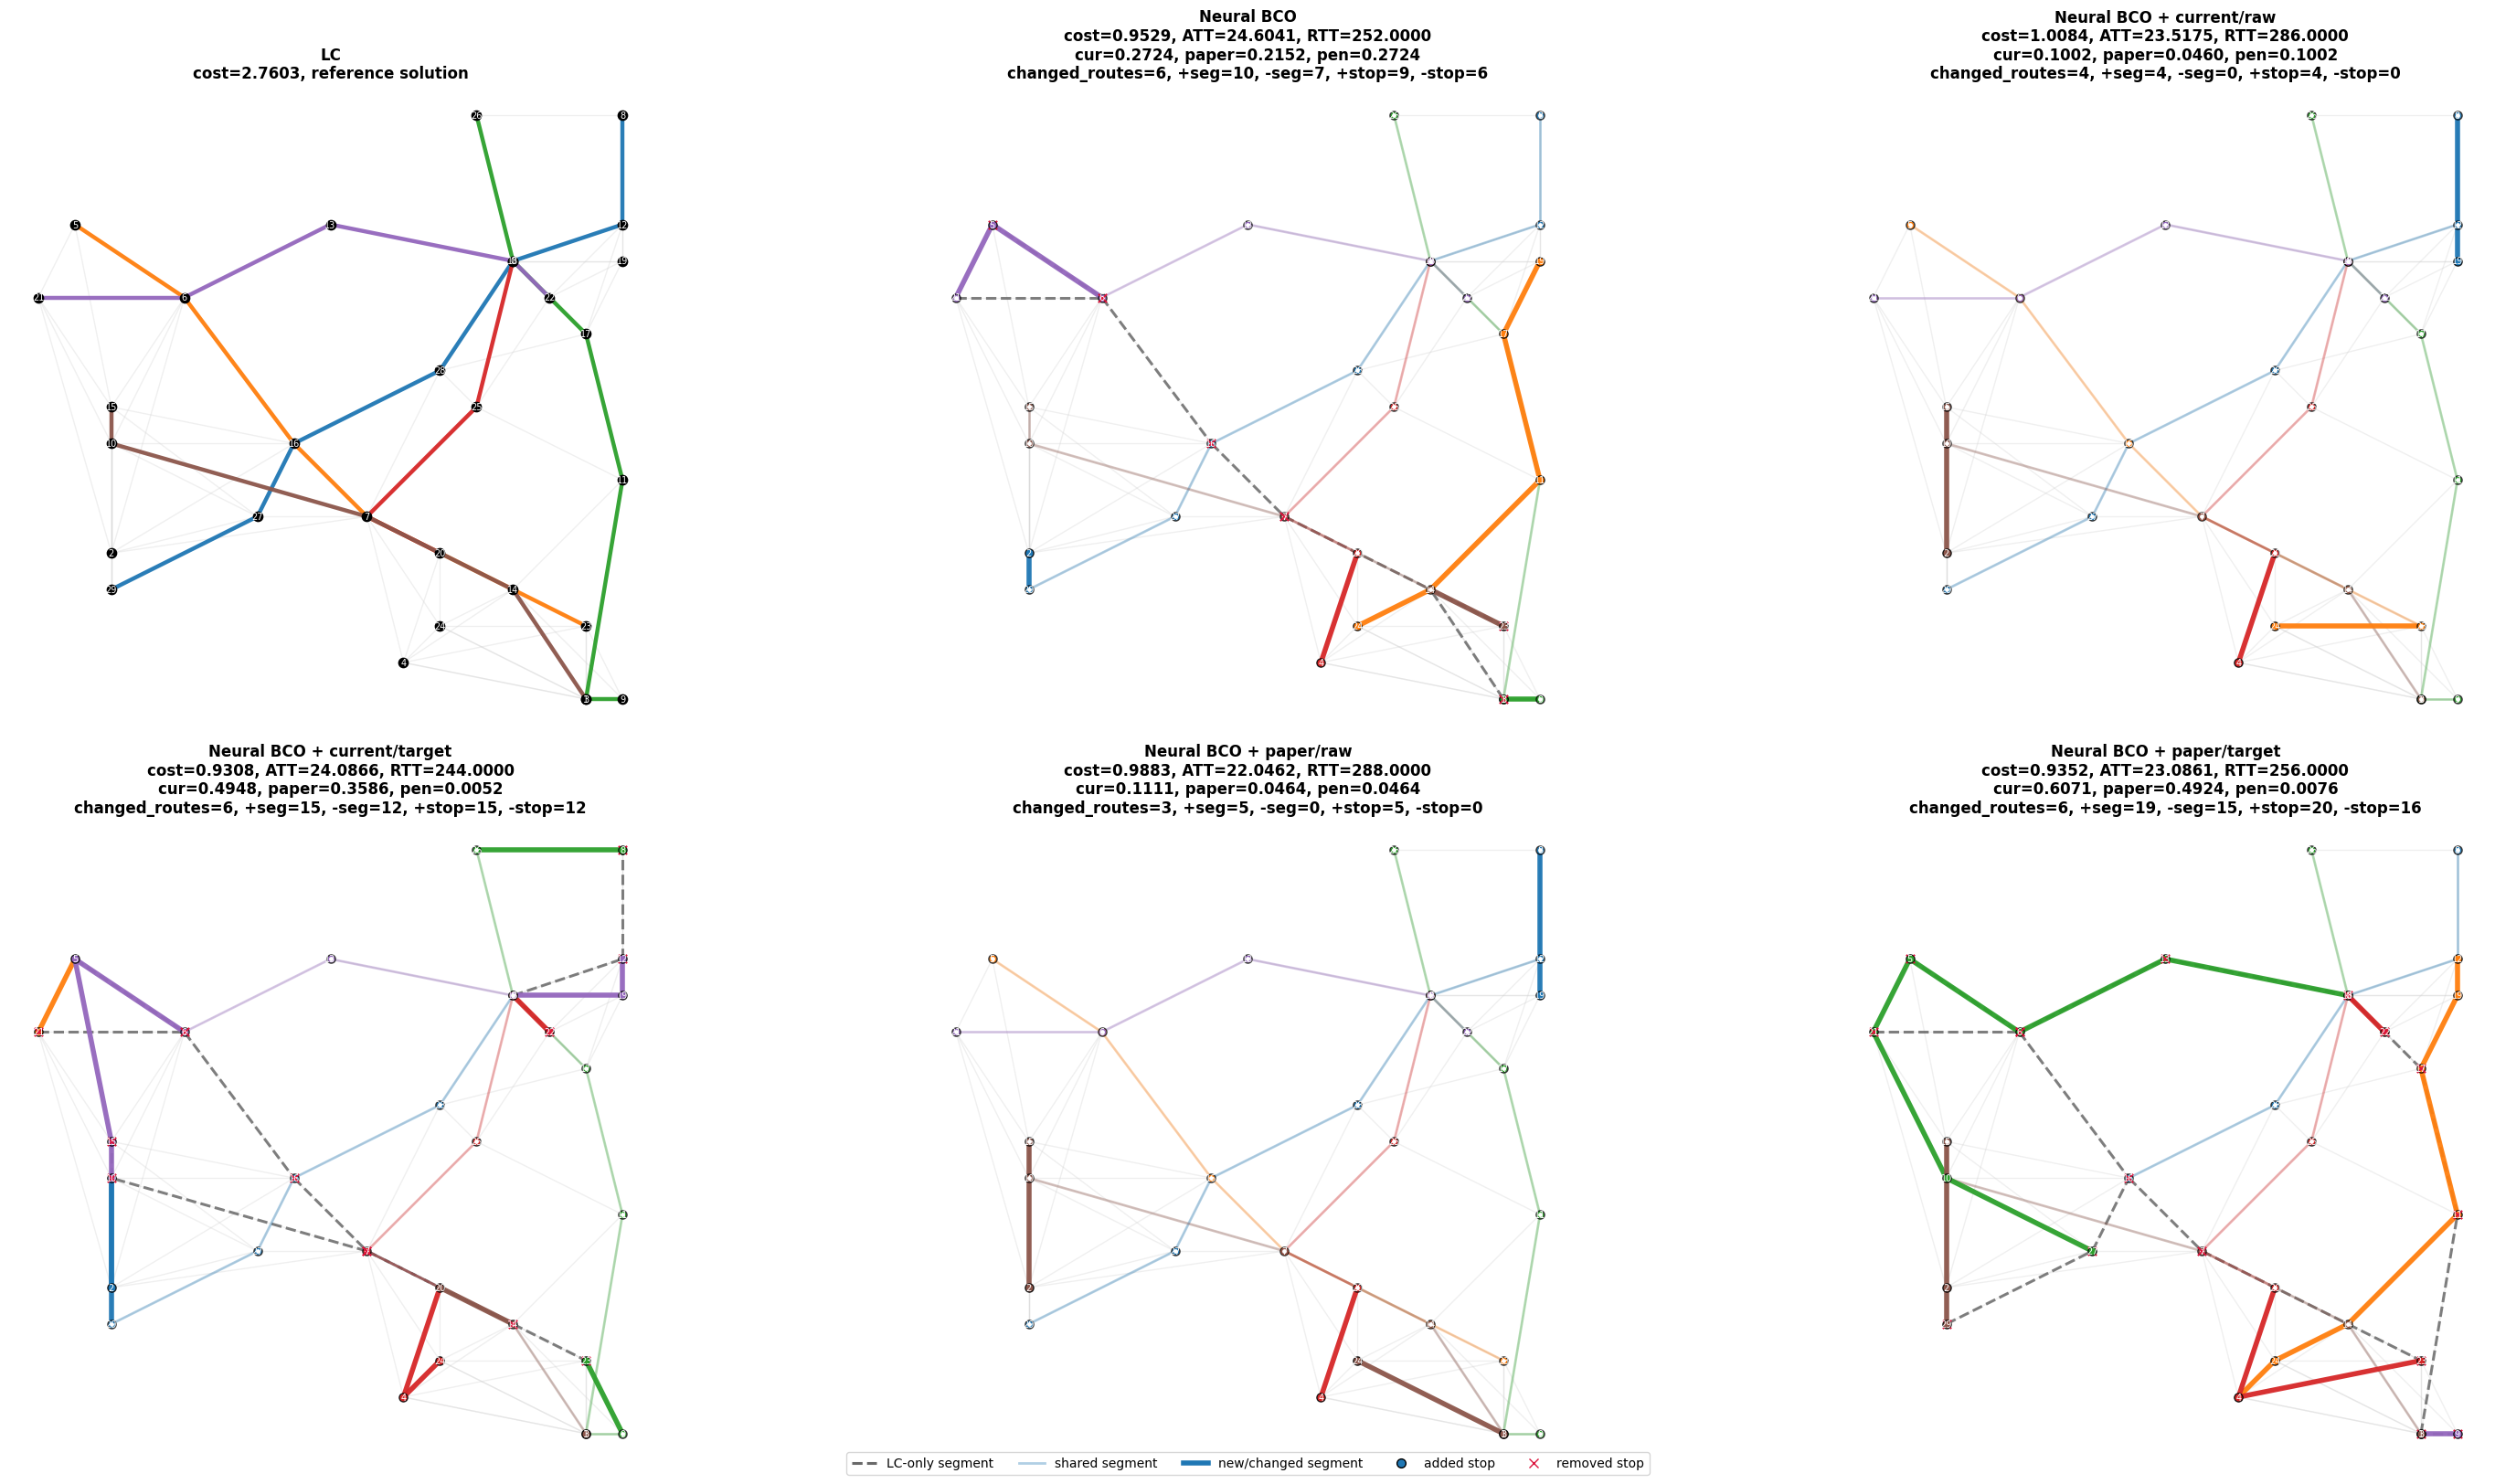

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_first_route_set(routes):
    routes = as_route_tensor(routes)
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(x) for x in route_tensor.tolist() if x != -1]


def route_edge_list(route):
    return [(route[i], route[i + 1]) for i in range(len(route) - 1)]


def undirected_edge_key(edge):
    u, v = edge
    return tuple(sorted((u, v)))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
                ax.plot(
                    [coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, linestyle="-", zorder=3):
    for u, v in edges:
        ax.plot(
            [coords[u, 0], coords[v, 0]],
            [coords[u, 1], coords[v, 1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, routes.shape[0])))
    for idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=6)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, max(routes.shape[0], reference_routes.shape[0]))))
    n_routes = max(routes.shape[0], reference_routes.shape[0])

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []
        color = colors[idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) in reference_edge_keys]
        added_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) not in reference_edge_keys]
        removed_edges = [edge for edge in reference_edges_in_order if undirected_edge_key(edge) not in route_edge_keys]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(coords[shared_nodes, 0], coords[shared_nodes, 1], s=20, facecolors="white", edgecolors=[color], linewidths=1.0, zorder=5)
        if added_nodes:
            ax.scatter(coords[added_nodes, 0], coords[added_nodes, 1], s=40, c=[color], edgecolors="black", linewidths=0.5, zorder=6)
        if removed_nodes:
            ax.scatter(coords[removed_nodes, 0], coords[removed_nodes, 1], s=45, c="crimson", marker="x", linewidths=1.4, zorder=6)

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=7)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
reference_row = comparison_rows[0]

fig, axes = plt.subplots(2, 3, figsize=(30, 16), constrained_layout=True)
for ax, row in zip(axes.flat, comparison_rows):
    if row["is_reference"]:
        subtitle = f"cost={_val(row['metrics'], 'cost'):.4f}, reference solution"
        plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
        continue

    change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
    subtitle = (
        f"cost={_val(row['metrics'], 'cost'):.4f}, ATT={_val(row['metrics'], 'ATT'):.4f}, RTT={_val(row['metrics'], 'RTT'):.4f}"
        f"\ncur={row['adj_cur']:.4f}, paper={row['adj_paper']:.4f}, pen={row['active_penalty']:.4f}"
        f"\nchanged_routes={change_summary['changed_routes']}, +seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, +stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
    )
    plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new/changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]
fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=5, frameon=True)
plt.show()


## 8. Pareto Front: ATT vs RTT Colored By Adj. cur

Each point is one evaluated method. Lower is better on both axes. Pareto-efficient methods are outlined in black and connected by a dashed line.


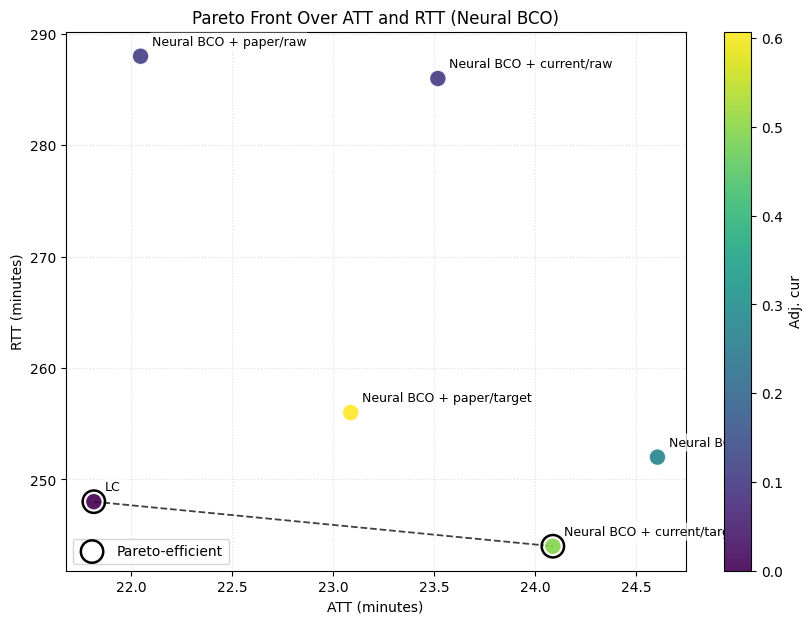

Pareto-efficient methods:
- LC: ATT=21.8152, RTT=248.0000, Adj. cur=0.0000
- Neural BCO + current/target: ATT=24.0866, RTT=244.0000, Adj. cur=0.4948


In [ ]:
import matplotlib.pyplot as plt


def is_pareto_efficient(points):
    points = np.asarray(points, dtype=float)
    n_points = points.shape[0]
    efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        for j in range(n_points):
            if i == j:
                continue
            dominates = np.all(points[j] <= points[i]) and np.any(points[j] < points[i])
            if dominates:
                efficient[i] = False
                break
    return efficient


pareto_labels = [row["label"] for row in comparison_rows]
pareto_att = [_val(row["metrics"], "ATT") for row in comparison_rows]
pareto_rtt = [_val(row["metrics"], "RTT") for row in comparison_rows]
pareto_adj_cur = [row["adj_cur"] for row in comparison_rows]

pareto_points = np.column_stack([pareto_att, pareto_rtt])
pareto_mask = is_pareto_efficient(pareto_points)
pareto_front = pareto_points[pareto_mask]
pareto_front_labels = [label for label, keep in zip(pareto_labels, pareto_mask) if keep]
pareto_front_adj = [adj for adj, keep in zip(pareto_adj_cur, pareto_mask) if keep]
pareto_front_order = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[pareto_front_order]
pareto_front_labels = [pareto_front_labels[idx] for idx in pareto_front_order]
pareto_front_adj = [pareto_front_adj[idx] for idx in pareto_front_order]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    pareto_att,
    pareto_rtt,
    c=pareto_adj_cur,
    cmap="viridis",
    s=150,
    alpha=0.9,
    edgecolors="white",
    linewidths=1.2,
    zorder=3,
)

ax.scatter(
    pareto_front[:, 0],
    pareto_front[:, 1],
    facecolors="none",
    edgecolors="black",
    s=260,
    linewidths=1.8,
    zorder=4,
    label="Pareto-efficient",
)
ax.plot(
    pareto_front[:, 0],
    pareto_front[:, 1],
    linestyle="--",
    color="black",
    linewidth=1.3,
    alpha=0.75,
    zorder=2,
)

for label, att, rtt in zip(pareto_labels, pareto_att, pareto_rtt):
    ax.annotate(
        label,
        (att, rtt),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Adj. cur")
ax.set_xlabel("ATT (minutes)")
ax.set_ylabel("RTT (minutes)")
ax.set_title(f"Pareto Front Over ATT and RTT ({BCO_METHOD_LABEL})")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(loc="best")
plt.show()

print("Pareto-efficient methods:")
for label, (att, rtt), adj_cur in zip(pareto_front_labels, pareto_front, pareto_front_adj):
    print(f"- {label}: ATT={att:.4f}, RTT={rtt:.4f}, Adj. cur={adj_cur:.4f}")
